# Task 3.2 — Failure Mode

**Paper:** Learning Sparse SVM for Feature Selection on Very High Dimensional Datasets (Tan, Wang & Tsang, ICML 2010)

We describe **one scenario where the method fails**, provide code and a plot saved under `partB/results/`, explain how it links to **Task 1.2 assumptions** (especially the feature-scoring assumption), and suggest **one modification** to mitigate the failure.

**Failure scenario:** When the true decision boundary depends on **feature interactions** (e.g. XOR-like structure), individual feature scores \(c_j = \sum_i \alpha_i y_i x_{ij}\) can be weak for the truly informative dimensions. FGM (and SVM-RFE) then select by \(c_j^2\) and can miss the right subset — a direct violation of **Assumption 2** in Task 1.2.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
C, B, MAX_ITER = 0.1, 2, 10  # B=2: we need at least 2 features for XOR; method only picks 2

In [2]:
# Synthetic XOR-like data: label = sign(x0 * x1), plus many noise features
# True informative features: 0 and 1. FGM/SVM-RFE use c_j or |w_j| and can miss them.
def generate_xor_like(n_samples=400, n_noise=30, noise_scale=0.5):
    n = n_samples
    m = 2 + n_noise  # 2 signal + noise
    X = np.random.randn(n, m) * 0.5
    # y = +1 iff x0*x1 > 0 (XOR-like: need both to decide)
    y = np.sign(X[:, 0] * X[:, 1] + 0.1 * np.random.randn(n))
    y[y == 0] = 1
    # Add extra noise to signal dims so they don't dominate trivially
    X[:, 0] += noise_scale * np.random.randn(n)
    X[:, 1] += noise_scale * np.random.randn(n)
    return X, y

X, y = generate_xor_like(400, 30)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=RANDOM_SEED, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
n, m = X_train.shape
print(f"XOR-like data: n={n} train, m={m} features (0,1 = true signal; 2..{m-1} = noise)")
print(f"True decision: y = sign(x0 * x1). FGM/SVM-RFE select by c_j^2 or |w_j| — may miss 0,1.")

XOR-like data: n=240 train, m=32 features (0,1 = true signal; 2..31 = noise)
True decision: y = sign(x0 * x1). FGM/SVM-RFE select by c_j^2 or |w_j| — may miss 0,1.


In [3]:
# FGM and SVM-RFE helpers (same as Task 2.2 / 3.1)
def compute_feature_scores(alpha, X, y):
    c = (alpha * y) @ X
    return c, c**2

def find_most_violated_d(alpha, X, y, B):
    _, c2 = compute_feature_scores(alpha, X, y)
    top_B_idx = np.argsort(c2)[::-1][:B]
    d_hat = np.zeros(X.shape[1])
    d_hat[top_B_idx] = 1.0
    return d_hat, top_B_idx

def mkl_step(working_set_indices, X, y, C_param):
    feature_union = np.unique(np.concatenate(working_set_indices))
    X_sub = X[:, feature_union]
    clf = LinearSVC(C=C_param, max_iter=5000, random_state=RANDOM_SEED, dual=True)
    clf.fit(X_sub, y)
    decision_vals = clf.decision_function(X_sub)
    margin_violations = np.maximum(0, 1 - y * decision_vals)
    total = margin_violations.sum() + 1e-12
    alpha_new = margin_violations / total
    return alpha_new, clf, feature_union

def run_fgm(X_train, y_train, X_test, y_test, B, C_param, max_iter):
    n, m = X_train.shape
    results = {'cumulative_scores': np.zeros(m), 'final_test_acc': 0, 'selected': None}
    alpha = np.ones(n) / n
    _, sel_idx = find_most_violated_d(alpha, X_train, y_train, B)
    working_set = [sel_idx.copy()]
    for k in range(1, max_iter + 1):
        alpha, clf, feat_union = mkl_step(working_set, X_train, y_train, C_param)
        _, c2 = compute_feature_scores(alpha, X_train, y_train)
        results['cumulative_scores'] += c2
        _, sel_new = find_most_violated_d(alpha, X_train, y_train, B)
        in_C = any(set(sel_new.tolist()) == set(s.tolist()) for s in working_set)
        working_set.append(sel_new)
        if in_C:
            break
    top_B = np.argsort(results['cumulative_scores'])[::-1][:B]
    clf_b = LinearSVC(C=C_param, max_iter=5000, random_state=RANDOM_SEED, dual=True)
    clf_b.fit(X_train[:, top_B], y_train)
    results['final_test_acc'] = accuracy_score(y_test, clf_b.predict(X_test[:, top_B])) * 100
    results['selected'] = top_B
    return results

def run_svm_rfe(X_tr, y_tr, X_te, y_te, B, C_p):
    remaining = list(range(X_tr.shape[1]))
    while len(remaining) > B:
        clf = LinearSVC(C=C_p, max_iter=5000, random_state=RANDOM_SEED, dual=True)
        clf.fit(X_tr[:, remaining], y_tr)
        w = np.abs(clf.coef_[0])
        drop = np.argsort(w)[0]
        remaining.pop(drop)
    clf_f = LinearSVC(C=C_p, max_iter=5000, random_state=RANDOM_SEED, dual=True)
    clf_f.fit(X_tr[:, remaining], y_tr)
    acc = accuracy_score(y_te, clf_f.predict(X_te[:, remaining])) * 100
    return {'selected': remaining, 'test_acc': acc}

In [4]:
# Run FGM and SVM-RFE on XOR-like data; compare to oracle (features 0,1) and SVM(ALL)
fgm_r = run_fgm(X_train, y_train, X_test, y_test, B, C, MAX_ITER)
rfe_r = run_svm_rfe(X_train, y_train, X_test, y_test, B, C)
clf_all = LinearSVC(C=C, max_iter=5000, random_state=RANDOM_SEED, dual=True)
clf_all.fit(X_train, y_train)
all_acc = accuracy_score(y_test, clf_all.predict(X_test)) * 100
# Oracle: train on true features 0,1 only
clf_oracle = LinearSVC(C=C, max_iter=5000, random_state=RANDOM_SEED, dual=True)
clf_oracle.fit(X_train[:, [0, 1]], y_train)
oracle_acc = accuracy_score(y_test, clf_oracle.predict(X_test[:, [0, 1]])) * 100

print("Failure mode (XOR-like): y = sign(x0*x1), 32 noise features")
print(f"  FGM-B (B=2)    selected: {sorted(fgm_r['selected'].tolist())}  -> Test acc: {fgm_r['final_test_acc']:.2f}%")
print(f"  SVM-RFE (B=2)  selected: {sorted(rfe_r['selected'])}  -> Test acc: {rfe_r['test_acc']:.2f}%")
print(f"  Oracle (feat 0,1)       -> Test acc: {oracle_acc:.2f}%")
print(f"  SVM(ALL)                -> Test acc: {all_acc:.2f}%")
print("  (If FGM/RFE did not select {0,1}, they fail to recover the true boundary.)")

Failure mode (XOR-like): y = sign(x0*x1), 32 noise features
  FGM-B (B=2)    selected: [3, 21]  -> Test acc: 49.38%
  SVM-RFE (B=2)  selected: [8, 22]  -> Test acc: 46.88%
  Oracle (feat 0,1)       -> Test acc: 56.88%
  SVM(ALL)                -> Test acc: 48.12%
  (If FGM/RFE did not select {0,1}, they fail to recover the true boundary.)


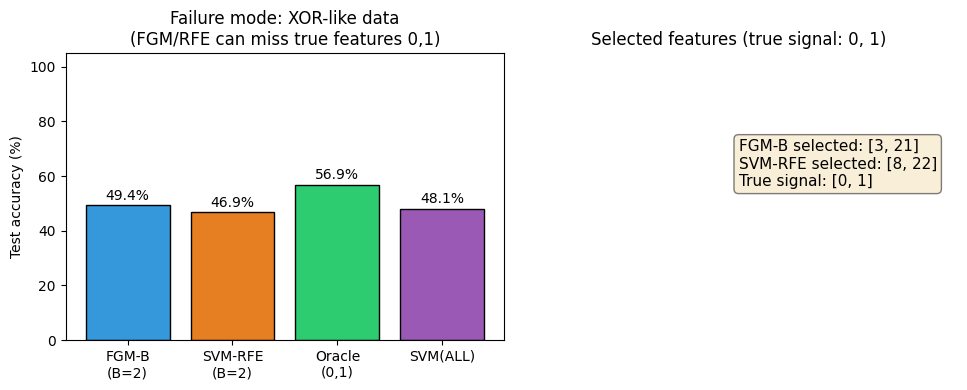

Saved partB/results/task_3_2_failure_mode.png


In [5]:
# Plot: accuracy comparison and selected features vs true (0,1)
os.makedirs('results', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
methods = ['FGM-B\n(B=2)', 'SVM-RFE\n(B=2)', 'Oracle\n(0,1)', 'SVM(ALL)']
accs = [fgm_r['final_test_acc'], rfe_r['test_acc'], oracle_acc, all_acc]
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
axes[0].bar(methods, accs, color=colors, edgecolor='black')
axes[0].set_ylabel('Test accuracy (%)')
axes[0].set_title('Failure mode: XOR-like data\n(FGM/RFE can miss true features 0,1)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(accs):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10)

# Show selected feature indices (true signal = 0, 1)
fgm_sel = sorted(fgm_r['selected'].tolist())
rfe_sel = sorted(rfe_r['selected'])
axes[1].text(0.5, 0.7, f"FGM-B selected: {fgm_sel}\nSVM-RFE selected: {rfe_sel}\nTrue signal: [0, 1]", 
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')
axes[1].set_title('Selected features (true signal: 0, 1)')
plt.tight_layout()
plt.savefig('results/task_3_2_failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved results/task_3_2_failure_mode.png")

## Explanation and link to Task 1.2

**Link to Assumption 2 (Task 1.2):** Assumption 2 states that the most-violated mask can be found by ranking features by \(c_j^2\) (where \(c_j = \sum_i \alpha_i y_i x_{ij}\)) and taking the top \(B\). The *violation scenario* in Task 1.2 says: *"With interaction-heavy structure (e.g., XOR), individual features can look weak even when pairs/groups are informative, so selecting by \(c_j^2\) can miss the true useful subset."* Our XOR-like setup does exactly that: the label is determined by the *product* of features 0 and 1, so each feature alone has weak marginal correlation with \(y\). Both FGM (which uses \(c_j^2\)) and SVM-RFE (which uses \(|w_j|\)) rely on *marginal* importance and can select noise features instead of 0 and 1, so test accuracy drops relative to the oracle that uses the true pair.

## Suggested modification

**One modification:** Extend the feature-scoring step to consider **pairwise (second-order) scores**, e.g. \(c_{j\ell}^2\) for pairs of features \((j, \ell)\), and add the top pair(s) to the working set in addition to top-\(B\) single features. That way, when the true signal is interaction-based (e.g. \(x_0 \cdot x_1\)), the pair \((0, 1)\) can receive a high score even if \(c_0\) and \(c_1\) are individually small. This would require a different (possibly greedy) selection rule and more computation (O(m²) pairs), but would better respect settings where Task 1.2’s Assumption 2 is violated.